## Preamble

In [1]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

nz=201; nx=201; h=10

fpeak=7; dt=0.003; nt=1000

ntr=201

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

nzsnap=249; nxsnap=249; nsnap=51
def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=17):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[:,:,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/GradientTest',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

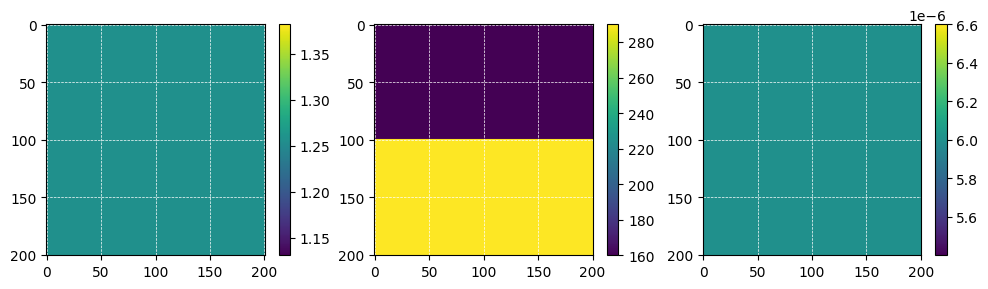

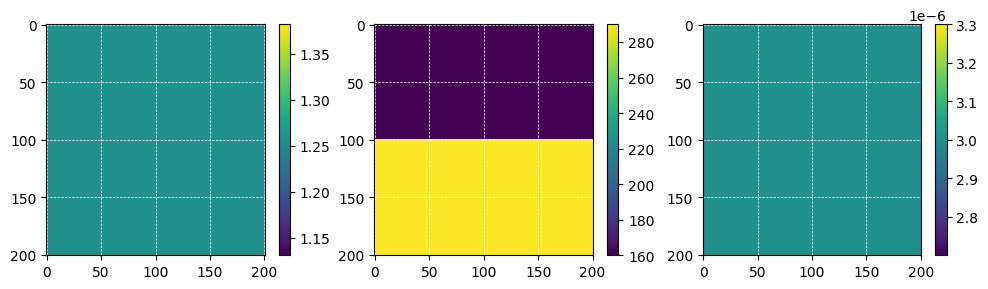

In [10]:
# True
cel = np.ones((nz,nx))
cel[:100,:]=160; cel[100:,:]=290
mu  =1.25663708*np.ones((nz,nx))
sgma=6e-6*np.ones((nz,nx))

model=np.concat((mu,cel,sgma),axis=1)
model.T.astype('float32').tofile('true')

# Background
sgma=3e-6*np.ones((nz,nx))

model=np.concat((mu,cel,sgma),axis=1)
model.T.astype('float32').tofile('init')


#plot
true=read('true',(3*nx,nz))
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(true[:,:nx])
plt.subplot(1,3,2); imshow(true[:,nx:2*nx])
plt.subplot(1,3,3); imshow(true[:,2*nx:])

init=read('init',(3*nx,nz))
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(init[:,:nx])
plt.subplot(1,3,2); imshow(init[:,nx:2*nx])
plt.subplot(1,3,3); imshow(init[:,2*nx:])

In [11]:
def epsrmur2celmu(epsr,mur):
    cel = 299.79563548 /np.sqrt(epsr*mur)
    mu  = 0.4*np.pi*mur
    return cel,mu

def celmu2epsrmur(cel,mu):
    mur = mu/(0.4*np.pi)
    epsr= (299.79563548/cel)**2/mur
    return epsr,mur

In [12]:
#topo
#!makevel nz=1   nx=$nx v000=78  > topo
!makevel nz=1   nx=$nx v000=90  > topo

In [13]:
%%writefile setup_default

MODEL_SIZE              '201   201   1'
MODEL_SPACING           '1.5   1.5   1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'true'
MODEL_ATTRIBUTES        'mu cel sgma'
MODEL_TIME_UNIT          1
NAIRL                    0

ACQUI_GEOMETRY          spread
FS                      '75 75  0'
FR                      '75  0  0'
DR                      '0  1.5 0'
NR                      201

SU_SCALCO   -10

SCOMP                   Ey
RCOMP                   Ey #'p vz'

WAVELET_TYPE            ricker
#T0                      0.5
#FILE_WAVELET            'fricker_dt6000.su'

IF_HICKS        F
IF_BLOOM        F

IF_USE_RANDOM   F

NT           1000
DT           0.003
FPEAK        7

SNAPSHOT                'Ey Hx Hz'


### for inversion ###
FILE_DATA_PREFIX        'results_obs/Ru_Shot'
WEIGHTING               'none'

PARAMETER               'sgma:0:9e-6'

SMOOTHING               'none'
#PRECO         'z^0'

#DESCENT_DIR     'random'  #'-curr%pg'

#LS_SCALING  'none'

IF_USE_CHECKPOINT        F

Overwriting setup_default


## TE Ey-Ey

### Obs & Syn data

In [14]:
!cp setup_default setup
!echo "DIR_OUT     results_obs" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 631328 Jun 26 21:59 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: 953cd92
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/26/2026
System time: 22:38:29
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0

In [15]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "DIR_OUT     results_syn" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 631328 Jun 26 21:59 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: 953cd92
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/26/2026
System time: 22:38:32
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0

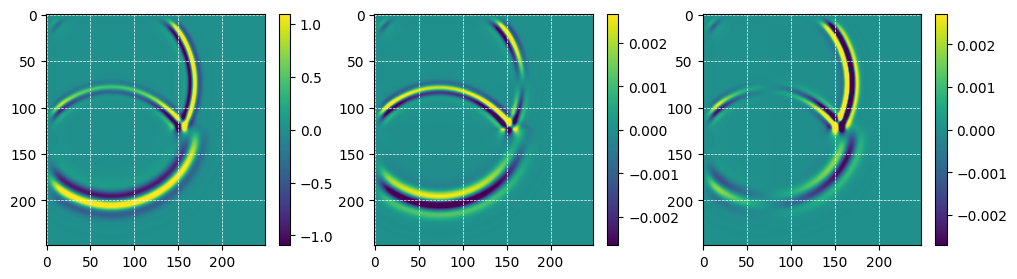

In [16]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results_obs/snap_fld_u%Ey',(51,249,249)),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results_obs/snap_fld_u%Hx',(51,249,249)),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results_obs/snap_fld_u%Hz',(51,249,249)),perc=98)

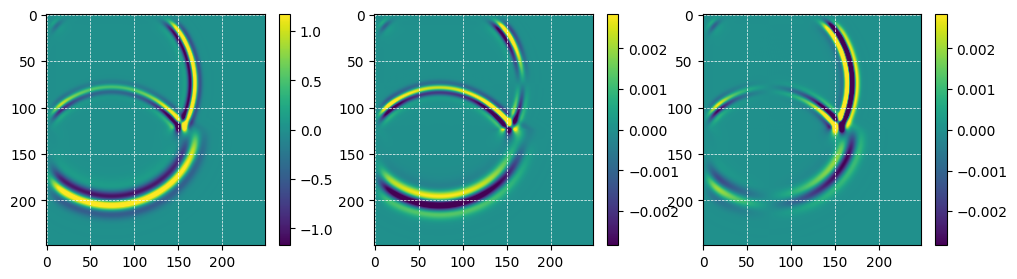

In [17]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results_syn/snap_fld_u%Ey',(51,249,249)),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results_syn/snap_fld_u%Hx',(51,249,249)),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results_syn/snap_fld_u%Hz',(51,249,249)),perc=98)

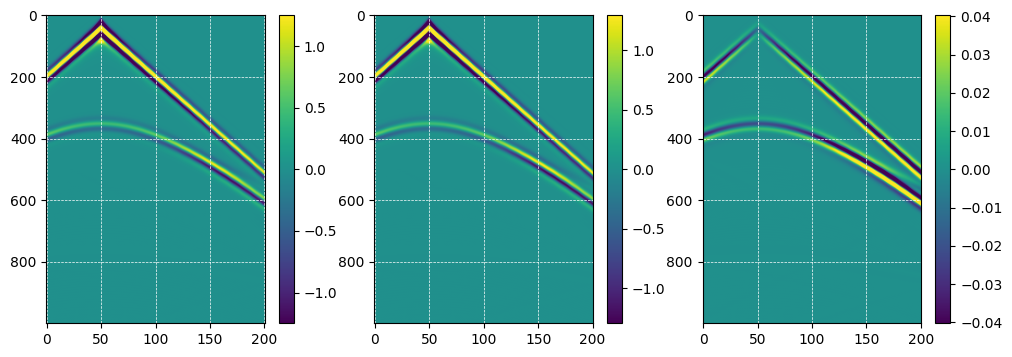

In [18]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,3); imshow(read_su('results_obs/Ru_Shot0001.su') \
                          -read_su('results_syn/Ru_Shot0001.su'),perc=98)

### Gradient

#### fwi_TE_FDSG_O4_epsr-mur-sgma

In [34]:
!cp setup_default setup
!echo 'FILE_MODEL   init' >> setup
!echo "PARAMETER   'sgma:0:9e-6'" >> setup
!echo 'JOB     gradient' >> setup
run(app='../../exe/fwi_TE_FDSG_O4_epsr-mur-sgma_Wolfe_NLCG_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 930000 Jun 26 22:57 ../../exe/fwi_TE_FDSG_O4_epsr-mur-sgma_Wolfe_NLCG_
 Git Commit: 953cd92
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/26/2026
System time: 22:57:43
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt 

 it----         500
 fld_a minmax values:  -187.989487       213.167343    
 fld_u minmax values:  -1.72540569       1.54152346    
 Elapsed time to load boundary            7.24416971E-03
 Elapsed time to update E       0.111130059    
 Elapsed time to rm source E     1.79952383E-03
 Elapsed time to update H         0.122708917    
 Total elapsed time for forward (min)   4.04804433E-03
  ---------------------------- 
 Elapsed time to add adjsource E    5.30344248E-03
 Elapsed time to update adj E      0.119026363    
 Elapsed time to update adj H        0.128425062    
 Elapsed time to extract&write fields        0.00000000    
 Elapsed time to correlate                   3.81058455E-03
 Total elapsed time for adjoint&correlate (min)   4.27609077E-03
 Total elapsed time (min):   8.32413509E-03
 Viewing the snapshots (if written) with SU ximage/xmovie:
 ximage < snap_rfield%*  n1=249 perc=99
 xmovie < snap_rfield%*  n1=249 n2=249 clip=?e-?? loop=2 title=%g
 ximage < snap_*  n1=201 perc

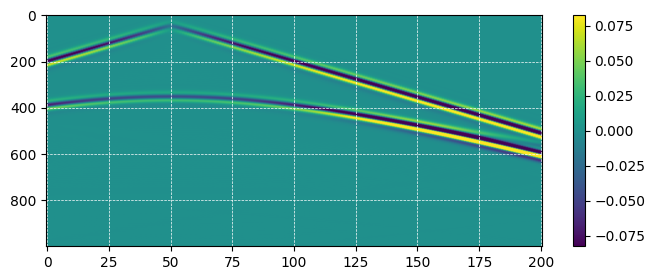

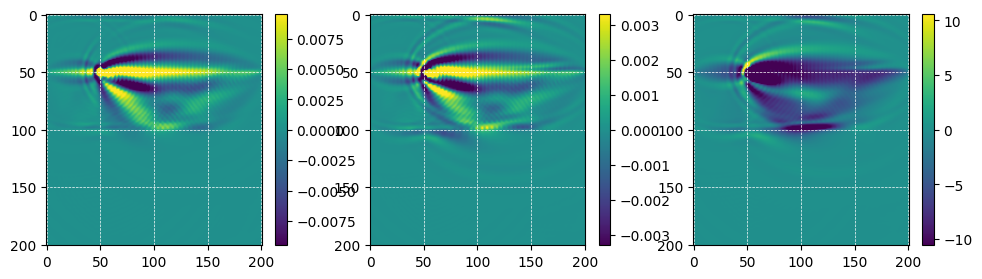

In [20]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz)) #gmur gepsr gsgma
plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(corr[:,:nx],perc=98)
plt.subplot(1,4,2); imshow(corr[:,nx:2*nx],perc=98)
plt.subplot(1,4,3); imshow(corr[:,2*nx:],perc=98)

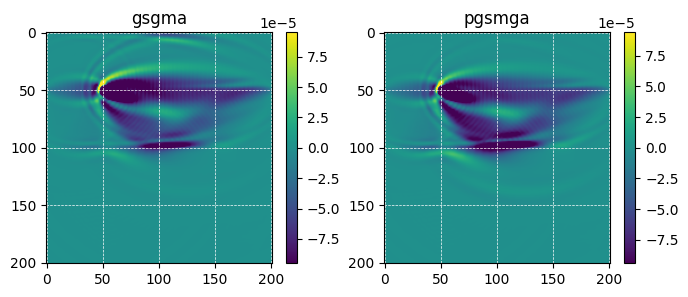

In [21]:
corr=read('results/qp0%g')
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results/qp0%g' ),perc=98,title='gsgma')
plt.subplot(1,2,2); imshow(read('results/qp0%pg'),perc=98,title='pgsmga')

### gradienttest_TE_FDSG_O4_epsr-mur-sgma

#### on gsgma

In [38]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER   'sgma:0:9e-6'" >> setup

!echo "ALPHAS '1e-10 1e-9 1e-8 1e-7 1e-6 1e-5' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_epsr-mur-sgma  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   1.00000001E-10   588897984.       589051712.      -1.53727993E+15  -3.50200171E+15   2.27805066     T
 1st cond   9.99999972E-10   585837568.       589051712.      -3.21414414E+15  -3.50200171E+15   1.08955967     T
 1st cond   9.99999994E-09   555115136.       589051712.      -3.39365767E+15  -3.50200171E+15   1.03192544     T
 1st cond   1.00000001E-07   307653760.       589051712.      -2.81397936E+15  -3.50200171E+15   1.24450159     T
 1st cond   9.99999997E-07   443421824.       589051712.      -1.45629892E+14  -3.50200171E+15   24.0472717     T
 1st cond   9.99999975E-06   996845312.       589051712.       4.07793597E+13  -3.50200171E+15  -85.8768158     F


In [ ]:
Alpha must be <1e-6 to be reasonable..